In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Mercedes-Benz firmasi avtomobillari narxini jamlagan jadvalni yuklab olamiz.

In [26]:
df = pd.read_csv("https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/merc.csv")
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,SLK,2005,5200,Automatic,63000,Petrol,325,32.1,1.8
1,S Class,2017,34948,Automatic,27000,Hybrid,20,61.4,2.1
2,SL CLASS,2016,49948,Automatic,6200,Petrol,555,28.0,5.5
3,G Class,2016,61948,Automatic,16000,Petrol,325,30.4,4.0
4,G Class,2016,73948,Automatic,4000,Petrol,325,30.1,4.0


In [27]:
df.shape

(13119, 9)

2010-yildan keyin chiqqan mashinalarni saqlab qolamiz

In [28]:
df = df[df['year'] > 2010]
df.shape

(12960, 9)

Faqat avtomat, mexanik va yarim-avtomat mashinalarni olib qolamiz

In [29]:
df.transmission.value_counts()

,count
transmission,
Semi-Auto,6844
Automatic,4686
Manual,1428
Other,2


In [30]:
df = df[df['transmission'] != 'Other']
df.transmission.value_counts()

,count
transmission,
Semi-Auto,6844
Automatic,4686
Manual,1428


Faqat benzin, dizel va gibrid mashinalarni olib qolamiz

In [31]:
df.fuelType.value_counts()

,count
fuelType,
Diesel,9114
Petrol,3665
Hybrid,173
Other,6


In [32]:
df = df[df['fuelType'] != 'Other']
df.fuelType.value_counts()

,count
fuelType,
Diesel,9114
Petrol,3665
Hybrid,173


Jadvaldagi narxlarning taqsimotini ko'ramiz:

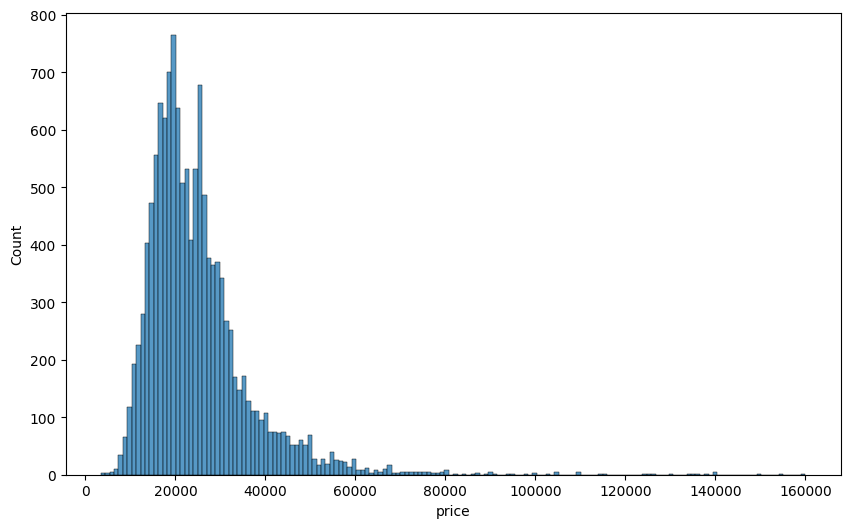

In [33]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x=df['price'])
plt.show()


`seaborn` da taqsimotlarni ko'rsatish uchun bir nechta funksiyalar mavjud.
Yuqorida ko'rganimiz `histplot` shulardan biri. Shuningdek, turli taqsimotlarni jamlaydigan yagona `displot` funksiyasi ham bor.

`displot` yoki `histplot` qay biridan foydalanish sizning o'zingizga bog'liq. Bu ikkisining fariq shundaku, `histplot` va biz pastroqda ko'radigan `kdeplot`,  `ecdfplot` funksiyalari yordamida chizmaga ko'proq o'zgartirishlar kiritish mumkin.

Batafsil: https://seaborn.pydata.org/generated/seaborn.displot.html

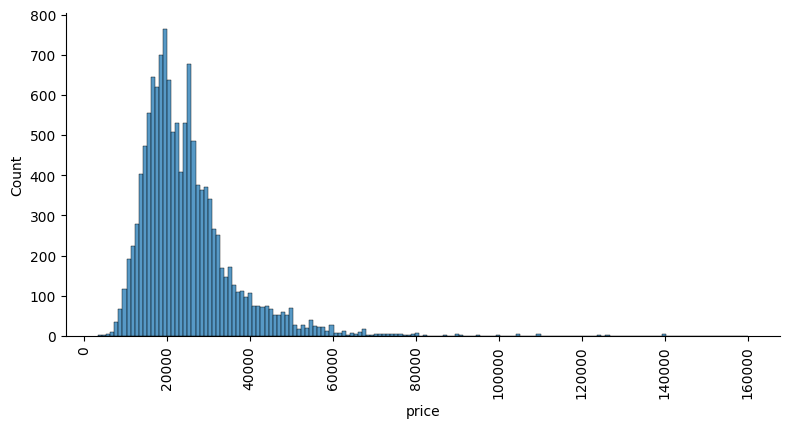

In [34]:
sns.displot(data=df, x='price', height=4, aspect=2)
plt.xticks(rotation=90)
plt.show()

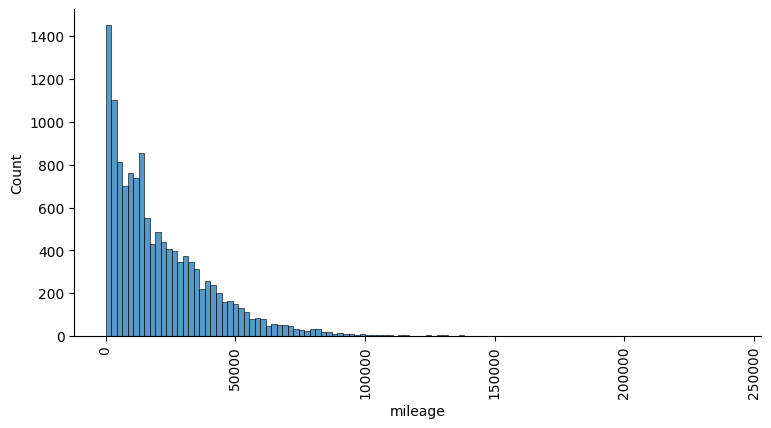

In [35]:
#km uchun taqsimot
sns.displot(data=df, x='mileage', height=4, aspect=2)
plt.xticks(rotation=90)
plt.show()

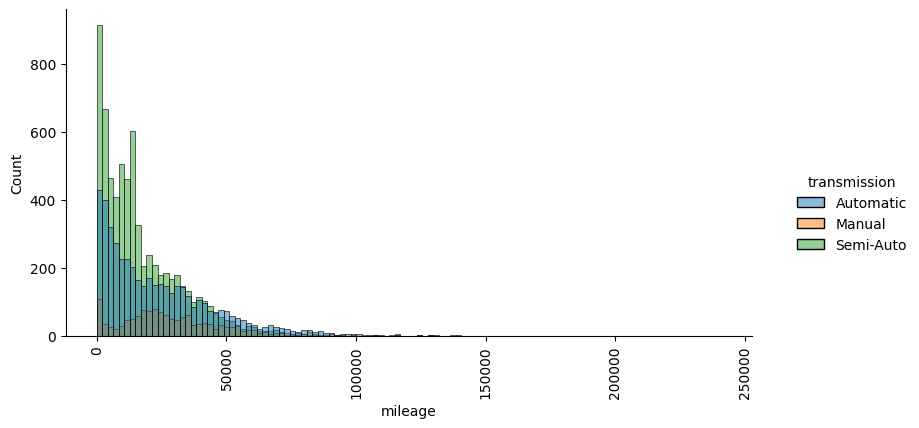

In [36]:
#km uchun taqsimot
sns.displot(data=df, x='mileage',hue='transmission', height=4, aspect=2)
plt.xticks(rotation=90)
plt.show()

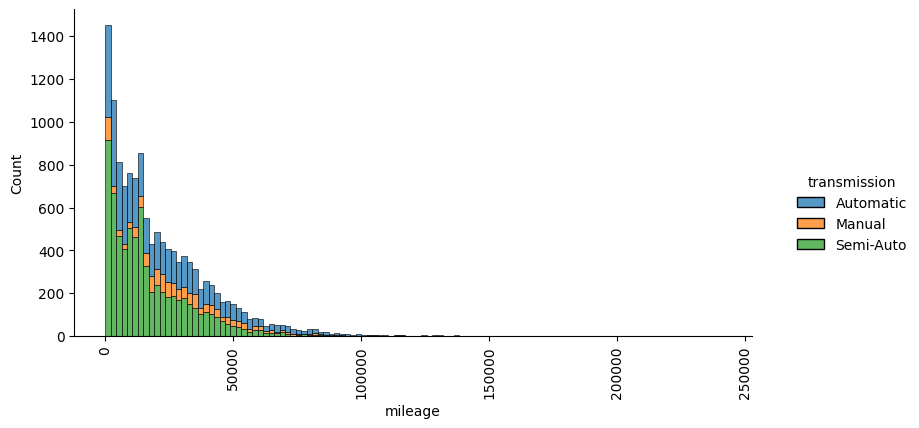

In [37]:
#km uchun taqsimot
sns.displot(data=df, x='mileage',hue='transmission',multiple='stack', height=4, aspect=2)
plt.xticks(rotation=90)
plt.show()

`col` parametri yordamida har bir grafikni ajratib chizish mumkin:


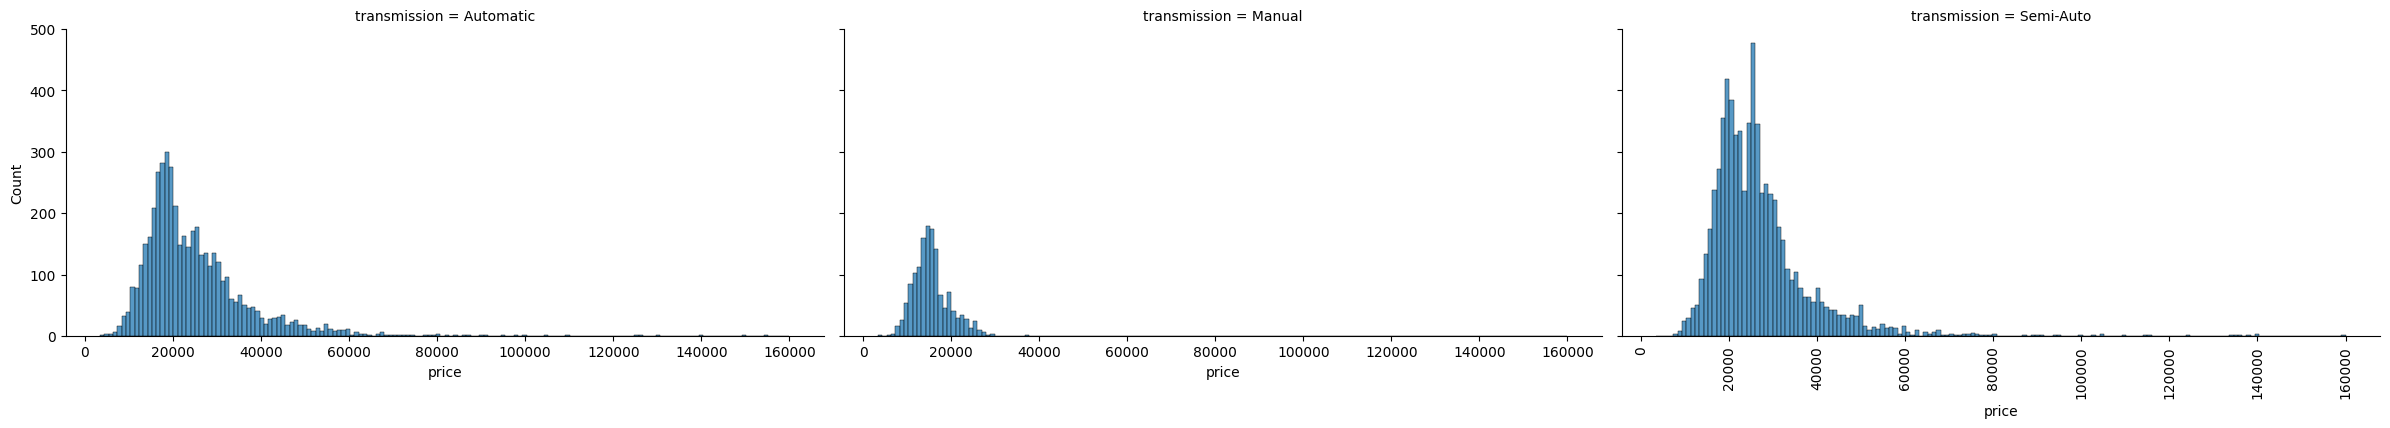

In [38]:
sns.displot(data=df, x='price',col='transmission', height=4, aspect=2)
plt.xticks(rotation=90)
plt.show()

### KDE - Kernel Density Estimation
Qiymatlar taqsimotini baholashning yana bir usuli bu - KDE, tasodifiy qiymatlar zichligini ko'rsatuvchi grafik.
KDE haqida to'liq ma'lumot: https://en.wikipedia.org/wiki/Kernel_density_estimation (rus tilida ham bor)

KDE grafik uchun `displot` yoki maxsus `kdeplot` funksiylaridan foydalanishimiz mumkin:

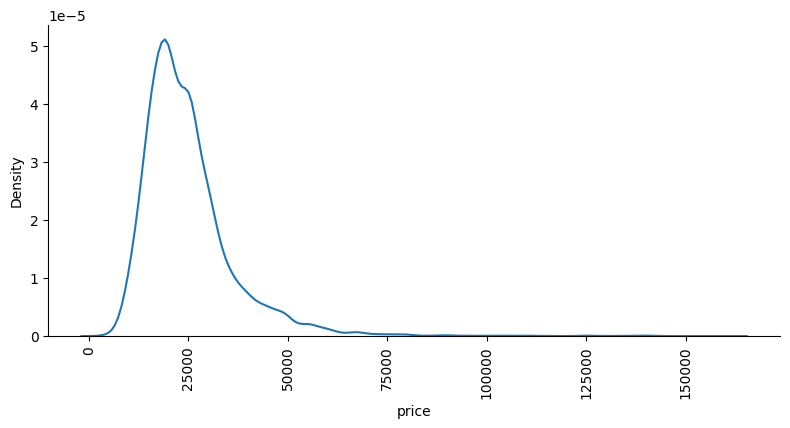

In [39]:
sns.displot(data=df, x='price', kind='kde', height=4, aspect=2)
plt.xticks(rotation=90)
plt.show()

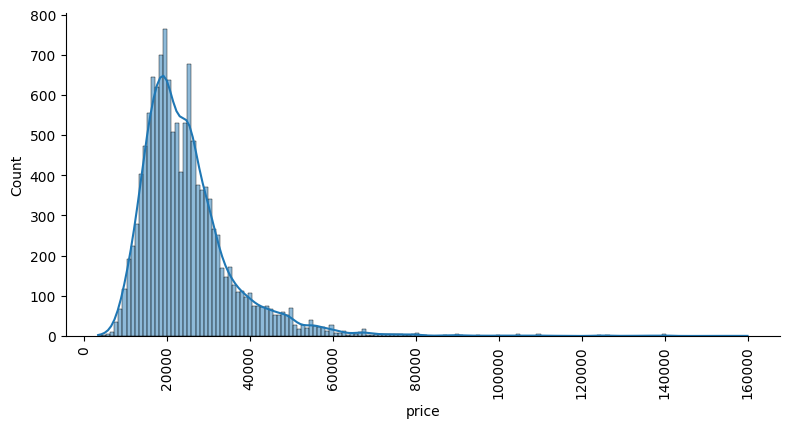

In [40]:
sns.displot(data=df, x='price', kde=True, height=4, aspect=2)
plt.xticks(rotation=90)
plt.show()

`kdeplot`

/tmp/ipykernel_981/192036554.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df, x='price', shade=True)


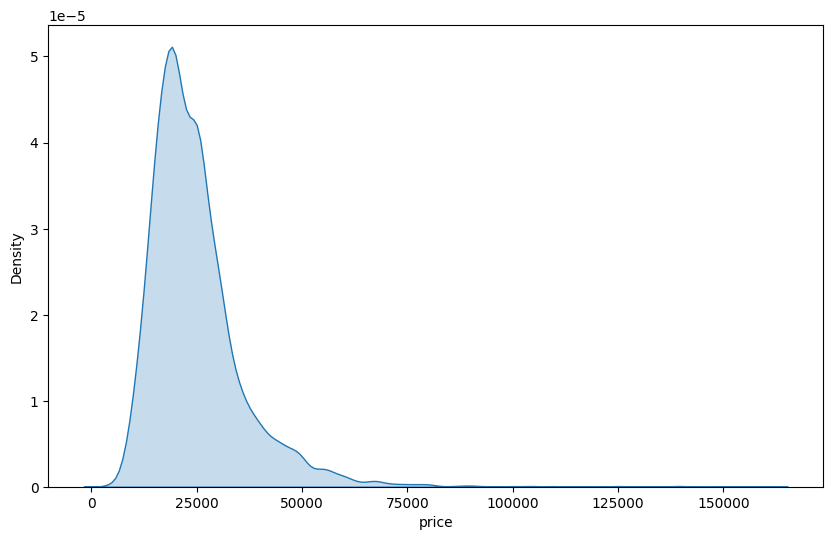

In [44]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='price', shade=True)
plt.show()

/tmp/ipykernel_981/2144652809.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df, x='price',hue='transmission', shade=True)


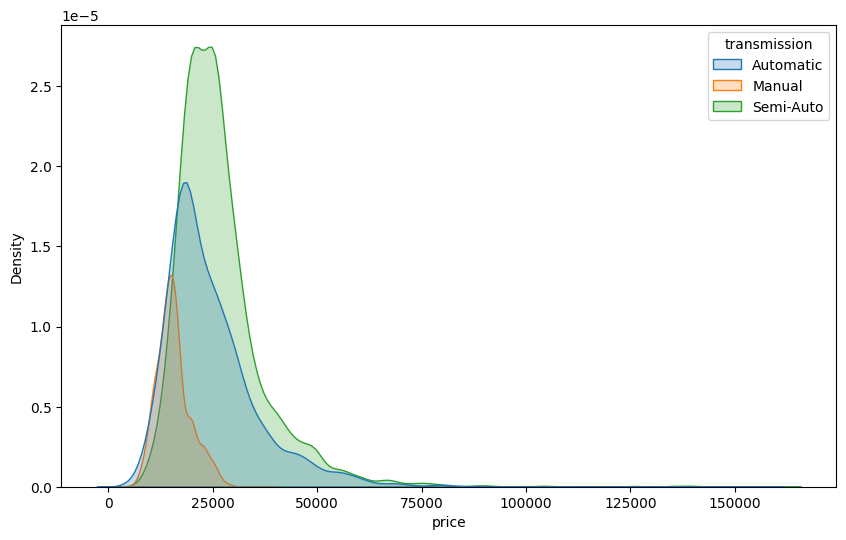

In [45]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='price',hue='transmission', shade=True)
plt.show()

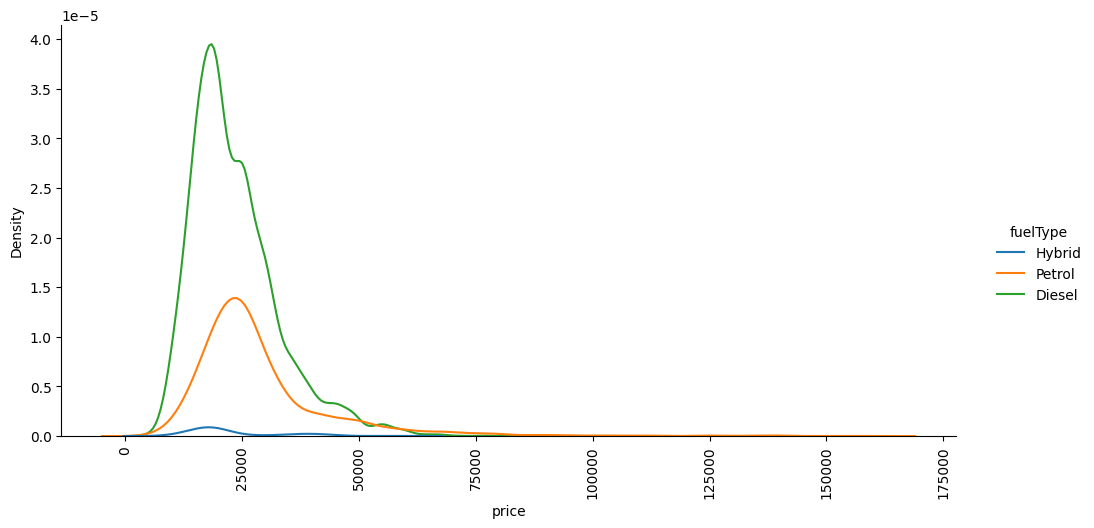

In [46]:
sns.displot(data=df, x='price', hue='fuelType', kind='kde', height=5, aspect=2)
plt.xticks(rotation=90)
plt.show()

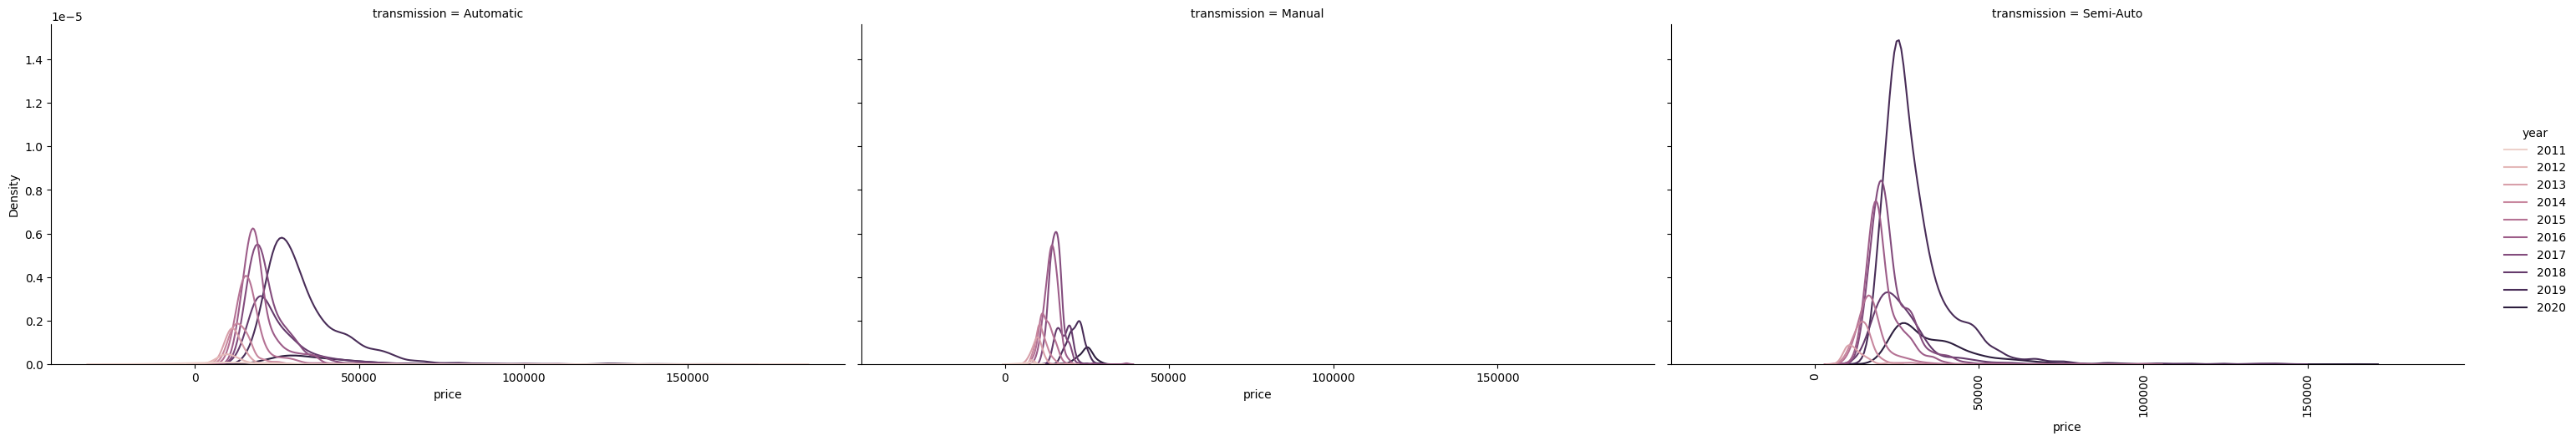

In [50]:
sns.displot(data=df, x='price', hue='year', col='transmission', kind='kde', height=5, aspect=2)
plt.xticks(rotation=90)
plt.show()

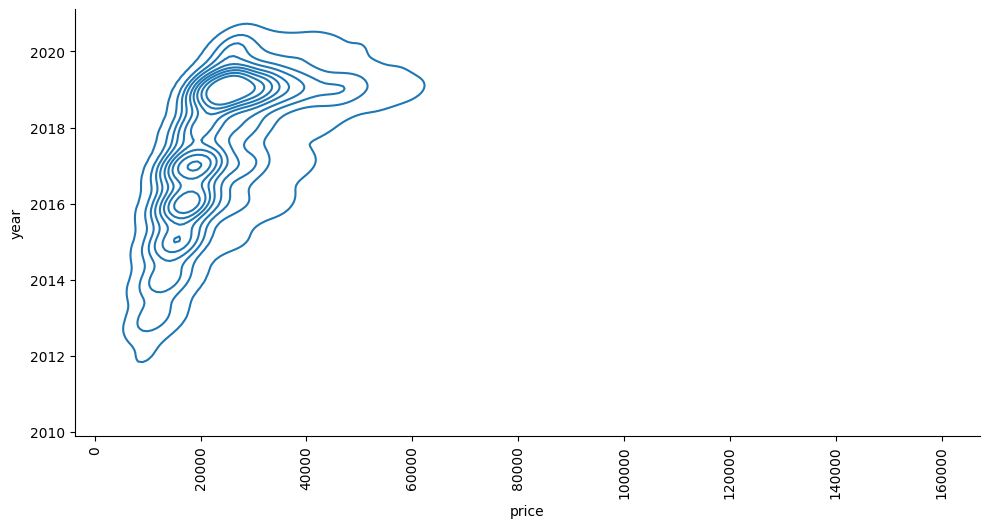

In [51]:
sns.displot(data=df, x='price', y='year', kind='kde', height=5, aspect=2)
plt.xticks(rotation=90)
plt.show()

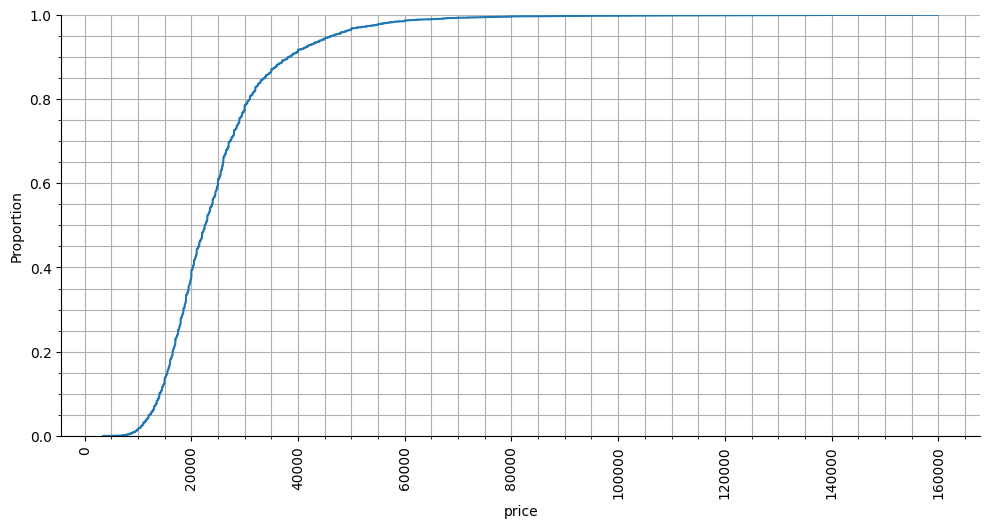

In [57]:
sns.displot(data=df, x='price', kind='ecdf', height=5, aspect=2)
plt.xticks(rotation=90)
plt.grid(which='both')
plt.minorticks_on()
plt.show()

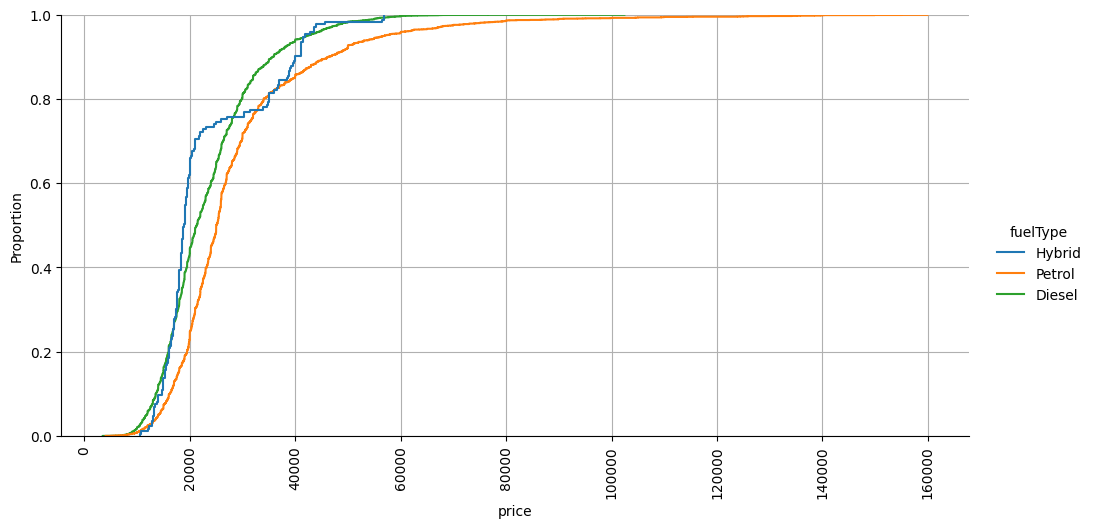

In [61]:
sns.displot(data=df, x='price', hue='fuelType', kind='ecdf', height=5, aspect=2)
plt.xticks(rotation=90)
plt.grid(which='both')
plt.show()

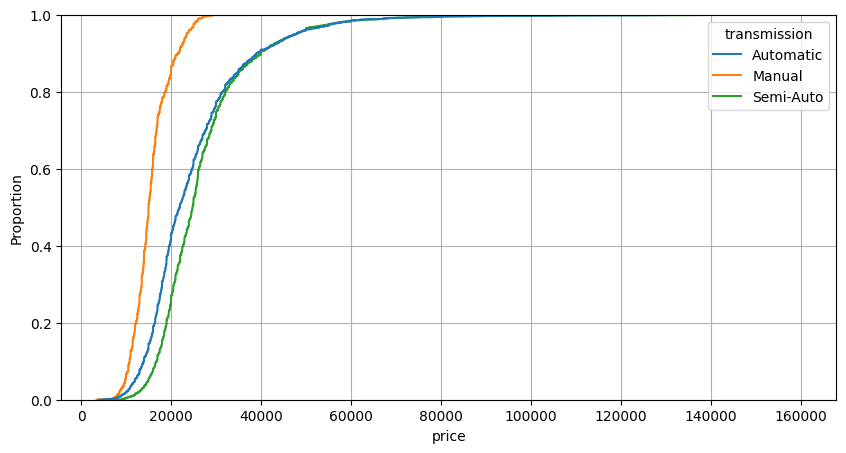

In [62]:
plt.figure(figsize=(10,5))
sns.ecdfplot(data=df, x="price", hue="transmission")
plt.grid()
plt.show()

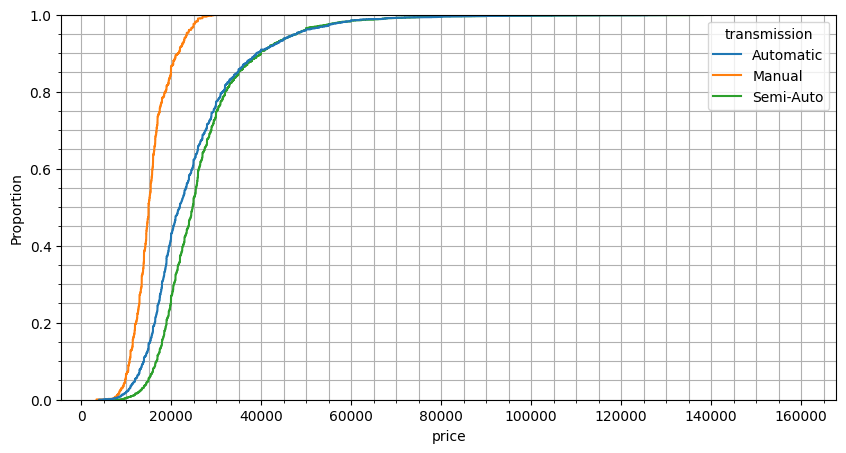

In [64]:
plt.figure(figsize=(10,5))
sns.ecdfplot(data=df, x="price", hue="transmission")
plt.grid(which='both')
plt.minorticks_on()
plt.show()